# Prototype 0416 v2.3 — RMT-Denoised Dynamic Correlation Graph

**Key changes from v2.2:**
- Marchenko-Pastur Random Matrix Theory denoising for all correlation matrices
- Per-sample rolling correlation denoised to remove estimation noise (γ=N/T=5.0)
- Average training correlation denoised for cleaner spectral coordinates
- Architecture unchanged from v2.2

**Motivation:** With T=60 days and N=300 stocks, the sample correlation matrix is rank-deficient (rank ≤ 60) and dominated by estimation noise. By Marchenko-Pastur law, eigenvalues below λ₊=(1+√(N/T))²≈10.47 are indistinguishable from pure noise. Only ~3-8 eigenvalues (market + sector factors) carry real signal. We were feeding 80%+ noise into WIRE attention.

**Config:** N=300, MP-denoised dynamic correlation, M_SPECTRAL=16, ω LR ×3, 5-seed evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
OUT_DIR = "/content/drive/MyDrive/3106_Projects/Projects/output/v_0416_v2.3"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Output → {OUT_DIR}")

Mounted at /content/drive
Output → /content/drive/MyDrive/3106_Projects/Projects/output/v_0416_v2.3


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from scipy.stats import spearmanr, ttest_rel
import json, time, warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}, PyTorch: {torch.__version__}")

Device: cuda, PyTorch: 2.10.0+cu128


## 1. Data Loading & Stock Filtering

In [ ]:
DATA = "/content/drive/MyDrive/3106_Projects/Projects/Data"
crsp = pd.read_csv(f"{DATA}/qf0egyr4ffi0pszj.csv", parse_dates=["DlyCalDt"])
crsp = crsp.sort_values(["PERMNO", "DlyCalDt"]).reset_index(drop=True)
compustat = pd.read_csv(f"{DATA}/gg3axrtvut5hi5hh.csv", parse_dates=["datadate"])
compustat = compustat.rename(columns={"LPERMNO": "PERMNO"})
print(f"CRSP: {crsp.shape[0]:,} rows, {crsp['PERMNO'].nunique()} stocks, "
      f"{crsp['DlyCalDt'].min().date()} to {crsp['DlyCalDt'].max().date()}")
print(f"Compustat: {compustat.shape[0]:,} rows, {compustat['PERMNO'].nunique()} stocks")

CRSP: 1,768,234 rows, 756 stocks, 2015-01-02 to 2025-12-31
Compustat: 27,236 rows, 745 stocks


In [ ]:
N_TARGET = 300

# 80% coverage filter
date_range = crsp["DlyCalDt"].nunique()
stock_counts = crsp.groupby("PERMNO")["DlyCalDt"].count()
valid_permnos = stock_counts[stock_counts >= date_range * 0.8].index

# Must have Compustat sector label
gsector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsector"]
valid_permnos = valid_permnos[valid_permnos.isin(gsector_map.index)]
print(f"After coverage + Compustat filter: {len(valid_permnos)} stocks available")

# Top N_TARGET by average daily volume
avg_vol = crsp[crsp["PERMNO"].isin(valid_permnos)].groupby("PERMNO")["DlyVol"].mean()
top_permnos = sorted(avg_vol.nlargest(N_TARGET).index.tolist())
crsp_sub = crsp[crsp["PERMNO"].isin(top_permnos)].copy()

permno_to_idx = {p: i for i, p in enumerate(top_permnos)}
N_STOCKS = len(top_permnos)
sectors = np.array([gsector_map.get(p, -1) for p in top_permnos])

print(f"\nSelected {N_STOCKS} stocks, {len(crsp_sub):,} daily records")
print(f"Min avg daily volume: {avg_vol[top_permnos].min():,.0f}")
print(f"\nGICS Sector distribution:")
for s, cnt in sorted(pd.Series(sectors).value_counts().items()):
    print(f"  Sector {int(s):2d}: {cnt:3d} stocks")

# Sanity check: estimate sector graph density
from math import comb
sector_edges_est = sum(comb(cnt, 2) for cnt in pd.Series(sectors).value_counts().values)
density_est = sector_edges_est / comb(N_STOCKS, 2)
print(f"\nEstimated sector graph: ~{sector_edges_est} edges, density≈{density_est:.4f} (need ≥0.02)")

After coverage + Compustat filter: 573 stocks available

Selected 300 stocks, 823,065 daily records
Min avg daily volume: 2,052,081

GICS Sector distribution:
  Sector 10:  31 stocks
  Sector 15:  10 stocks
  Sector 20:  24 stocks
  Sector 25:  55 stocks
  Sector 30:  26 stocks
  Sector 35:  21 stocks
  Sector 40:  44 stocks
  Sector 45:  40 stocks
  Sector 50:  19 stocks
  Sector 55:  17 stocks
  Sector 60:  13 stocks

Estimated sector graph: ~4917 edges, density≈0.1096 (need ≥0.02)


## 2. Feature Engineering (25 input features)

**Base OHLCV (5):** O/C, H/C, L/C, log(Vol), Return
**Technical (16):** RSI, MACD hist, Bollinger %B, ATR/Close, P/SMA(5,20,60), Mom(5d,20d), RVol(5d,20d), Vol ratio, log vol chg, B/A spread, Turnover, Excess return
**Fundamentals (4):** ROE, Leverage, Profit margin, log(Assets)

In [ ]:
print("Computing technical indicators per stock...")
t0 = time.time()

def add_technicals(df):
    # Add 16 technical indicator columns, computed per stock.
    results = []
    total = df["PERMNO"].nunique()
    for i, (permno, g) in enumerate(df.groupby("PERMNO")):
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{total} stocks...")
        g = g.sort_values("DlyCalDt").copy()
        c, h, l, v, r = g["DlyPrc"], g["DlyHigh"], g["DlyLow"], g["DlyVol"], g["DlyRet"]
        cs = c.replace(0, np.nan)

        # RSI(14) — [0, 1]
        delta = c.diff()
        avg_gain = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
        avg_loss = (-delta).clip(lower=0).ewm(span=14, adjust=False).mean()
        g["RSI"] = (100 - 100 / (1 + avg_gain / avg_loss.replace(0, np.nan))) / 100

        # MACD histogram (normalized by close)
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        macd = ema12 - ema26
        g["MACD_hist"] = (macd - macd.ewm(span=9, adjust=False).mean()) / cs

        # Bollinger %B (20-day, 2σ)
        sma20 = c.rolling(20, min_periods=10).mean()
        std20 = c.rolling(20, min_periods=10).std()
        g["BB_pctB"] = (c - (sma20 - 2 * std20)) / (4 * std20).replace(0, np.nan)

        # ATR(14) / Close
        tr = pd.concat([h - l, (h - c.shift(1)).abs(), (l - c.shift(1)).abs()], axis=1).max(axis=1)
        g["ATR_norm"] = tr.rolling(14, min_periods=7).mean() / cs

        # Price / SMA ratios
        for w in [5, 20, 60]:
            sma = c.rolling(w, min_periods=max(1, w // 2)).mean()
            g[f"close_sma{w}"] = c / sma.replace(0, np.nan)

        # Momentum returns
        for w in [5, 20]:
            g[f"mom_{w}d"] = c.pct_change(w)

        # Realized volatility (annualized)
        for w in [5, 20]:
            g[f"rvol_{w}d"] = r.rolling(w, min_periods=max(1, w // 2)).std() * np.sqrt(252)

        # Volume ratio (vs 20-day MA)
        g["vol_ratio"] = v / v.rolling(20, min_periods=10).mean().replace(0, np.nan)

        # Log volume change (1-day)
        g["log_vol_chg"] = np.log1p(v).diff()

        # Bid-ask spread / close
        g["ba_spread"] = (g["DlyAsk"] - g["DlyBid"]) / cs

        # Turnover (daily vol / shares outstanding)
        g["turnover"] = v / (g["ShrOut"].replace(0, np.nan) * 1000)

        # Excess return (vs S&P 500)
        g["excess_ret"] = r - g["sprtrn"]

        results.append(g)
    return pd.concat(results, ignore_index=True)

crsp_sub = add_technicals(crsp_sub)
print(f"Done in {time.time() - t0:.1f}s — {len(crsp_sub):,} rows")

Computing technical indicators per stock...
  100/300 stocks...
  200/300 stocks...
  300/300 stocks...
Done in 4.3s — 823,065 rows


In [ ]:
# ── Feature column definitions ──
TECH_COLS = ["RSI", "MACD_hist", "BB_pctB", "ATR_norm",
             "close_sma5", "close_sma20", "close_sma60",
             "mom_5d", "mom_20d", "rvol_5d", "rvol_20d",
             "vol_ratio", "log_vol_chg", "ba_spread", "turnover", "excess_ret"]
FUND_COLS = ["roe", "leverage", "profit_margin", "log_assets"]
FEATURE_NAMES = (["close", "open_close", "high_close", "low_close", "log_vol", "return"]
                 + TECH_COLS + FUND_COLS)

# ── Build (T, N, 22) base tensor: OHLCV + technicals ──
def build_feature_tensor(df, permnos, p2i):
    dates = sorted(df["DlyCalDt"].unique())
    T, N = len(dates), len(permnos)
    F = 6 + len(TECH_COLS)
    feat = np.full((T, N, F), np.nan, dtype=np.float32)
    d2t = {d: t for t, d in enumerate(dates)}
    df = df.copy()
    df["_t"] = df["DlyCalDt"].map(d2t)
    df["_n"] = df["PERMNO"].map(p2i)
    df = df.dropna(subset=["_t", "_n"])
    t = df["_t"].astype(int).values
    n = df["_n"].astype(int).values
    c = df["DlyPrc"].values.astype(np.float32)
    cs = np.where(c == 0, 1.0, c)
    feat[t, n, 0] = c                                    # raw close (for target)
    feat[t, n, 1] = df["DlyOpen"].values / cs             # O/C
    feat[t, n, 2] = df["DlyHigh"].values / cs             # H/C
    feat[t, n, 3] = df["DlyLow"].values / cs              # L/C
    feat[t, n, 4] = np.log1p(df["DlyVol"].values)         # log volume
    feat[t, n, 5] = df["DlyRet"].values                   # return
    for i, col in enumerate(TECH_COLS):
        feat[t, n, 6 + i] = df[col].values
    return feat, dates

features, dates = build_feature_tensor(crsp_sub, top_permnos, permno_to_idx)
print(f"Base tensor: {features.shape} (T, N, F_base={features.shape[2]})")

# ── Add Compustat fundamentals (point-in-time via report date) ──
fund = compustat[["PERMNO", "datadate", "rdq", "atq", "ceqq", "niq"]].copy()
fund["rdq"] = pd.to_datetime(fund["rdq"])
fund["avail_date"] = fund["rdq"].fillna(fund["datadate"] + pd.Timedelta(days=45))

def safe_ratio(num, denom, clip=10):
    return (num / denom.replace(0, np.nan)).clip(-clip, clip)

fund["roe"] = safe_ratio(fund["niq"], fund["ceqq"])
fund["leverage"] = safe_ratio(fund["atq"], fund["ceqq"])
fund["profit_margin"] = safe_ratio(fund["niq"], fund["atq"])
fund["log_assets"] = np.log1p(fund["atq"].clip(lower=0))

T, N, F_base = features.shape
fund_feat = np.full((T, N, len(FUND_COLS)), np.nan, dtype=np.float32)
dates_arr = np.array(dates)

print("Merging fundamentals...")
for permno in top_permnos:
    ni = permno_to_idx[permno]
    sf = fund[fund["PERMNO"] == permno].sort_values("avail_date")
    for _, row in sf.iterrows():
        mask = dates_arr >= row["avail_date"]
        if mask.any():
            fund_feat[mask, ni, :] = [row[c] for c in FUND_COLS]

features = np.concatenate([features, fund_feat], axis=2)

# ── Forward-fill → backward-fill NaN per stock ──
print("Filling NaN...")
for n in range(N):
    df_tmp = pd.DataFrame(features[:, n, :])
    features[:, n, :] = df_tmp.ffill().bfill().values

# ── Clip extreme values for technical features ──
clip_map = {
    6:  (0, 1),        # RSI
    7:  (-0.1, 0.1),   # MACD_hist
    8:  (-1, 2),        # BB_%B
    9:  (0, 0.5),       # ATR_norm
    10: (0.5, 2.0),     # close/SMA5
    11: (0.5, 2.0),     # close/SMA20
    12: (0.5, 2.0),     # close/SMA60
    13: (-0.5, 0.5),    # mom_5d
    14: (-0.5, 0.5),    # mom_20d
    15: (0, 2.0),       # rvol_5d
    16: (0, 2.0),       # rvol_20d
    17: (0, 10.0),      # vol_ratio
    19: (-0.01, 0.1),   # ba_spread
    20: (0, 0.1),       # turnover
    21: (-0.2, 0.2),    # excess_ret
}
for idx, (lo, hi) in clip_map.items():
    features[:, :, idx] = np.clip(features[:, :, idx], lo, hi)

features = np.nan_to_num(features, nan=0.0)
INPUT_DIM = features.shape[2] - 1  # exclude raw close at index 0

print(f"\nFinal tensor: {features.shape}, INPUT_DIM={INPUT_DIM}")
print(f"Remaining NaN: {np.isnan(features).sum()}")
print(f"\nFeature summary (index | name | mean | std | min | max):")
for i, name in enumerate(FEATURE_NAMES):
    v = features[:, :, i]
    print(f"  {i:2d} {name:18s}  {v.mean():+9.4f}  {v.std():8.4f}  [{v.min():+.4f}, {v.max():+.4f}]")

Base tensor: (2766, 300, 22) (T, N, F_base=22)
Merging fundamentals...
Filling NaN...

Final tensor: (2766, 300, 26), INPUT_DIM=25
Remaining NaN: 0

Feature summary (index | name | mean | std | min | max):
   0 close                +95.4290  173.7532  [+0.0000, +3731.4099]
   1 open_close            +1.0001    0.0197  [+0.4874, +1.7045]
   2 high_close            +1.0134    0.0158  [+1.0000, +2.4948]
   3 low_close             +0.9866    0.0151  [+0.4280, +1.0000]
   4 log_vol              +15.2748    0.9602  [+4.6151, +20.5113]
   5 return                +0.0005    0.0245  [-0.6087, +1.5629]
   6 RSI                   +0.5125    0.1714  [+0.0000, +1.0000]
   7 MACD_hist             +0.0001    0.0093  [-0.1000, +0.1000]
   8 BB_pctB               +0.5238    0.3308  [-0.5621, +1.5621]
   9 ATR_norm              +0.0290    0.0198  [+0.0015, +0.5000]
  10 close_sma5            +0.9987    0.0398  [+0.5000, +2.0000]
  11 close_sma20           +1.0004    0.0667  [+0.5000, +2.0000]
  12 close

## 3. Marchenko-Pastur Denoising, Correlation Graph & Spectral Coordinates

  Marchenko-Pastur Denoising Diagnostics

  Average correlation (for spectral coords):
    T=1936, N=300, γ=N/T=0.155
    MP upper bound λ₊ = 1.94
    Signal eigenvalues: 13/300
    Variance explained by signal: 59.2%

  Per-sample rolling correlation (for attention bias):
    T=60, N=300, γ=N/T=5.00
    MP upper bound λ₊ = 10.47
    Rank of sample corr ≤ 60 (out of 300)
    ⇒ 240 eigenvalues are exactly 0 (noise)
    ⇒ Remaining ~60 eigenvalues: only those > 10.5 are signal
    ⇒ Expected ~3-8 signal eigenvalues (market + sector factors)

  Denoised correlation graph: 300 nodes, 44,802 edges, density=0.9989
  Sector graph (comparison): 4,917 edges, density=0.1096
  Spectral coords: (300, 16), spectral gap=0.8316


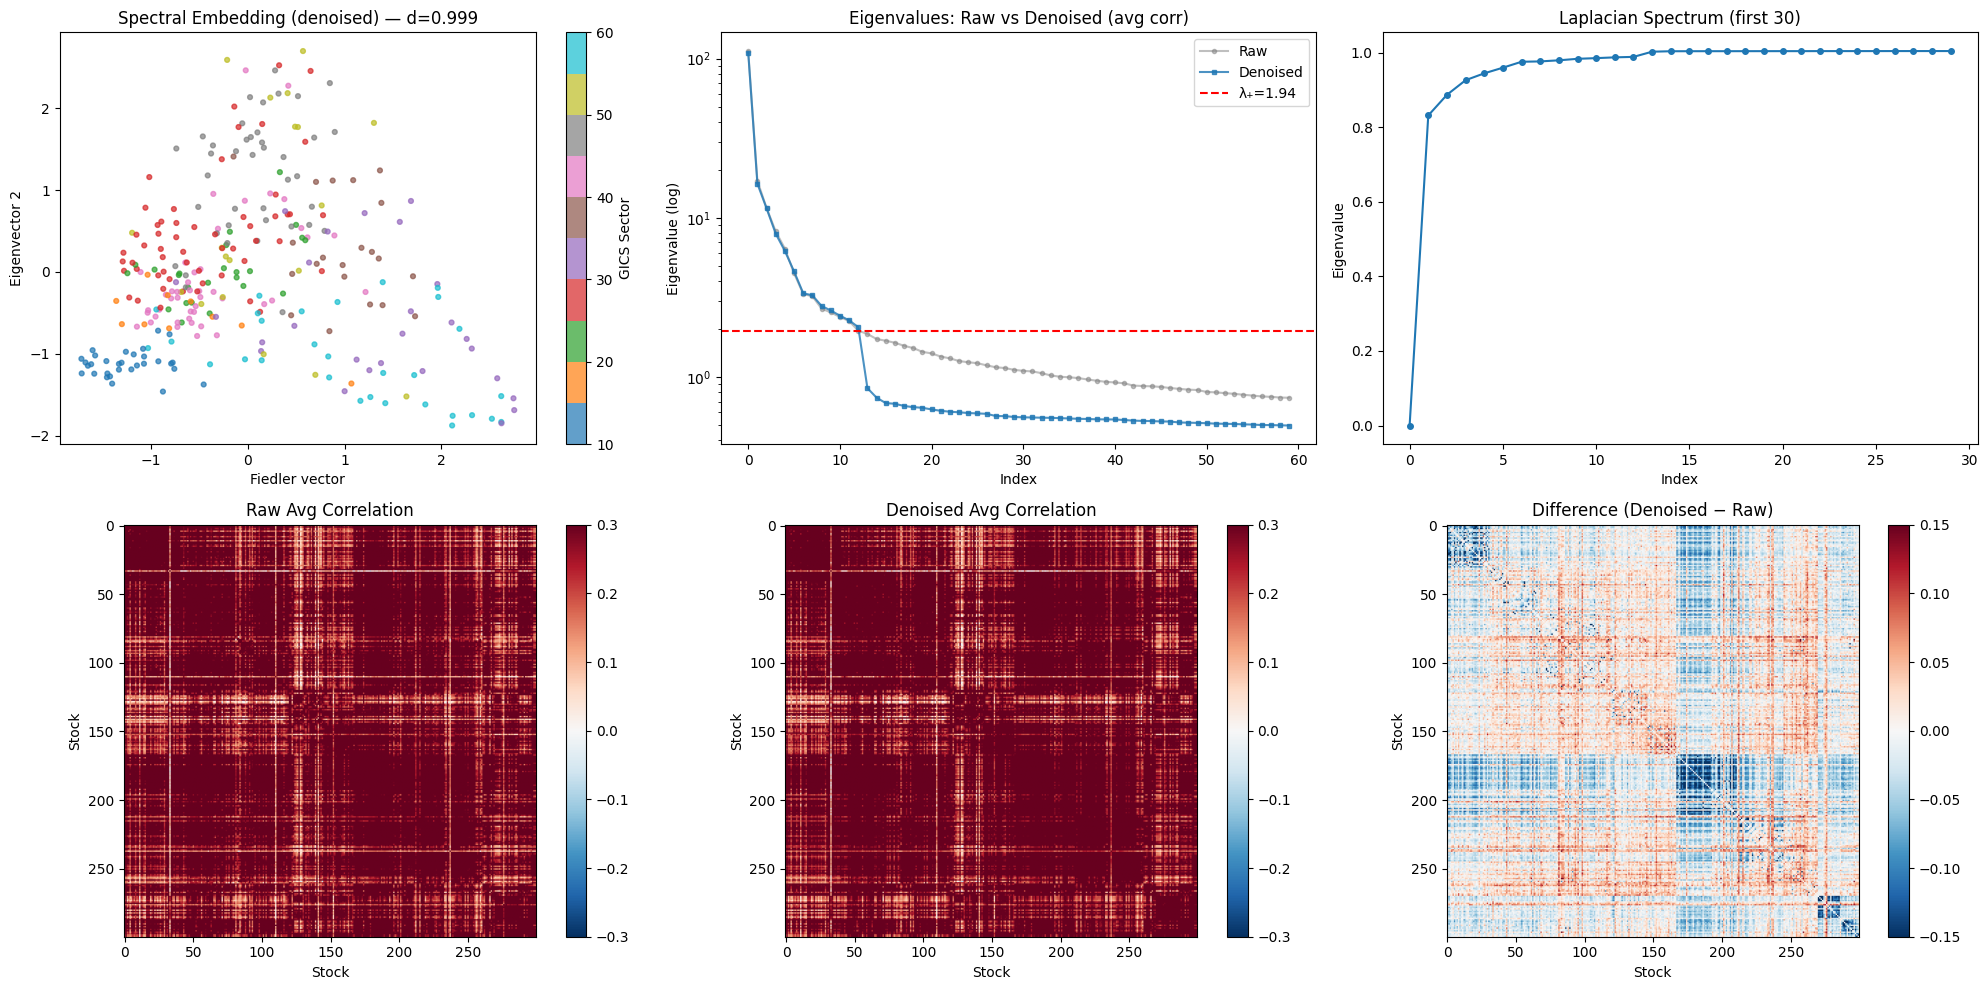


Correlation stats (upper triangle):
  Raw:      mean=0.3529, std=0.1368, [-0.069, 0.993]
  Denoised: mean=0.3506, std=0.1168, [-0.079, 0.670]
  Mean |diff|: 0.0326


In [ ]:
M_SPECTRAL = 16
CORR_WINDOW = 1000

# ══════════════════════════════════════════════════════════════
#  Marchenko-Pastur RMT Denoising
# ══════════════════════════════════════════════════════════════
# For a T×N random matrix with N/T = γ, the bulk eigenvalues of the
# sample correlation lie in [(1-√γ)², (1+√γ)²]. Eigenvalues above λ₊
# are signal; everything else is estimation noise.
#
# When N > T (our case: 300 > 60), the matrix is rank-deficient with
# (N-T) zero eigenvalues — all noise. Among the T non-zero eigenvalues,
# only those exceeding λ₊ carry real structure.

def mp_denoise(corr, T, N):
    """Denoise correlation matrix using Marchenko-Pastur Random Matrix Theory.

    Args:
        corr: (N, N) sample correlation matrix
        T: number of time observations used to estimate corr
        N: number of variables (stocks)

    Returns:
        corr_denoised: (N, N) denoised correlation matrix (float32)
        n_signal: number of eigenvalues identified as signal
    """
    eigenvalues, eigenvectors = np.linalg.eigh(corr)

    # MP upper bound for noise eigenvalues
    gamma = N / T
    lambda_plus = (1 + np.sqrt(gamma)) ** 2

    signal_mask = eigenvalues > lambda_plus
    n_signal = signal_mask.sum()

    if 0 < n_signal < N:
        # Replace noise eigenvalues with their mean to preserve trace = N
        signal_sum = eigenvalues[signal_mask].sum()
        noise_val = max((N - signal_sum) / (N - n_signal), 0.0)
        eigenvalues[~signal_mask] = noise_val

    # Reconstruct: C = V diag(λ) V^T
    corr_denoised = (eigenvectors * eigenvalues) @ eigenvectors.T

    # Re-normalize so diagonal = 1 (correlation matrix)
    d = np.sqrt(np.maximum(np.diag(corr_denoised), 1e-10))
    corr_denoised /= np.outer(d, d)
    np.fill_diagonal(corr_denoised, 1.0)

    return corr_denoised.astype(np.float32), n_signal

# ══════════════════════════════════════════════════════════════
#  Average correlation from training period (for spectral coords)
# ══════════════════════════════════════════════════════════════
returns_all = features[:, :, 5]  # (T, N) daily returns
T_total = returns_all.shape[0]
train_end = int(0.7 * T_total)
returns_train = returns_all[:train_end]
T_train = returns_train.shape[0]

# Raw average correlation
avg_corr_raw = np.corrcoef(returns_train.T)  # (N, N)
avg_corr_raw = np.nan_to_num(avg_corr_raw, nan=0.0)

# Denoise
avg_corr, n_sig_avg = mp_denoise(avg_corr_raw, T_train, N_STOCKS)

print(f"{'=' * 60}")
print(f"  Marchenko-Pastur Denoising Diagnostics")
print(f"{'=' * 60}")
print(f"\n  Average correlation (for spectral coords):")
print(f"    T={T_train}, N={N_STOCKS}, γ=N/T={N_STOCKS/T_train:.3f}")
print(f"    MP upper bound λ₊ = {(1 + np.sqrt(N_STOCKS/T_train))**2:.2f}")
print(f"    Signal eigenvalues: {n_sig_avg}/{N_STOCKS}")
print(f"    Variance explained by signal: "
      f"{np.linalg.eigvalsh(avg_corr_raw)[avg_corr_raw.shape[0] - n_sig_avg:].sum() / N_STOCKS:.1%}")

gamma_rolling = N_STOCKS / CORR_WINDOW
lambda_plus_rolling = (1 + np.sqrt(gamma_rolling)) ** 2
print(f"\n  Per-sample rolling correlation (for attention bias):")
print(f"    T={CORR_WINDOW}, N={N_STOCKS}, γ=N/T={gamma_rolling:.2f}")
print(f"    MP upper bound λ₊ = {lambda_plus_rolling:.2f}")
print(f"    Rank of sample corr ≤ {CORR_WINDOW} (out of {N_STOCKS})")
print(f"    ⇒ {N_STOCKS - CORR_WINDOW} eigenvalues are exactly 0 (noise)")
print(f"    ⇒ Remaining ~{CORR_WINDOW} eigenvalues: only those > {lambda_plus_rolling:.1f} are signal")
print(f"    ⇒ Expected ~3-8 signal eigenvalues (market + sector factors)")

# ══════════════════════════════════════════════════════════════
#  Build graph from denoised correlation
# ══════════════════════════════════════════════════════════════
A_corr = np.clip(avg_corr, 0, 1).astype(np.float32)
np.fill_diagonal(A_corr, 0)
n_edges = int((A_corr > 0).sum() / 2)
density = n_edges / (N_STOCKS * (N_STOCKS - 1) / 2)
print(f"\n  Denoised correlation graph: {N_STOCKS} nodes, {n_edges:,} edges, density={density:.4f}")

# Sector graph for comparison
def build_adjacency(labels):
    L = labels.reshape(-1, 1)
    A = ((L == L.T) & (L != -1)).astype(np.float32)
    np.fill_diagonal(A, 0)
    return A

A_sector = build_adjacency(sectors)
sector_edges = int(A_sector.sum() / 2)
print(f"  Sector graph (comparison): {sector_edges:,} edges, "
      f"density={sector_edges / (N_STOCKS * (N_STOCKS - 1) / 2):.4f}")

# ══════════════════════════════════════════════════════════════
#  Spectral coordinates from denoised Laplacian
# ══════════════════════════════════════════════════════════════
L_norm = laplacian(A_corr, normed=True)
eigenvalues_lap, eigenvectors_lap = eigh(L_norm)
spectral_coords = eigenvectors_lap[:, 1:M_SPECTRAL + 1].astype(np.float32)
spectral_coords = (spectral_coords - spectral_coords.mean(axis=0)) / (spectral_coords.std(axis=0) + 1e-8)
print(f"  Spectral coords: {spectral_coords.shape}, spectral gap={eigenvalues_lap[1]:.4f}")

# ══════════════════════════════════════════════════════════════
#  Visualization: Raw vs Denoised
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 1: Spectral embedding & eigenvalue spectrum
sc_plot = axes[0, 0].scatter(spectral_coords[:, 0], spectral_coords[:, 1],
                              c=sectors, cmap="tab10", alpha=0.7, s=12)
axes[0, 0].set_xlabel("Fiedler vector"); axes[0, 0].set_ylabel("Eigenvector 2")
axes[0, 0].set_title(f"Spectral Embedding (denoised) — d={density:.3f}")
plt.colorbar(sc_plot, ax=axes[0, 0], label="GICS Sector")

eig_raw = np.sort(np.linalg.eigvalsh(avg_corr_raw))[::-1]
eig_denoised = np.sort(np.linalg.eigvalsh(avg_corr))[::-1]
axes[0, 1].semilogy(eig_raw[:60], "o-", markersize=3, alpha=0.5, label="Raw", color="gray")
axes[0, 1].semilogy(eig_denoised[:60], "s-", markersize=3, alpha=0.8, label="Denoised", color="tab:blue")
axes[0, 1].axhline((1 + np.sqrt(N_STOCKS/T_train))**2, color="red", ls="--",
                    label=f"λ₊={(1 + np.sqrt(N_STOCKS/T_train))**2:.2f}")
axes[0, 1].set_xlabel("Index"); axes[0, 1].set_ylabel("Eigenvalue (log)")
axes[0, 1].set_title("Eigenvalues: Raw vs Denoised (avg corr)")
axes[0, 1].legend()

axes[0, 2].plot(eigenvalues_lap[:30], "o-", markersize=4)
axes[0, 2].set_xlabel("Index"); axes[0, 2].set_ylabel("Eigenvalue")
axes[0, 2].set_title("Laplacian Spectrum (first 30)")

# Row 2: Raw vs Denoised correlation heatmaps & difference
sector_order = np.argsort(sectors)
im1 = axes[1, 0].imshow(avg_corr_raw[np.ix_(sector_order, sector_order)],
                          cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[1, 0].set_title("Raw Avg Correlation")
plt.colorbar(im1, ax=axes[1, 0])

im2 = axes[1, 1].imshow(avg_corr[np.ix_(sector_order, sector_order)],
                          cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[1, 1].set_title("Denoised Avg Correlation")
plt.colorbar(im2, ax=axes[1, 1])

diff_corr = avg_corr - avg_corr_raw
im3 = axes[1, 2].imshow(diff_corr[np.ix_(sector_order, sector_order)],
                          cmap="RdBu_r", vmin=-0.15, vmax=0.15)
axes[1, 2].set_title("Difference (Denoised − Raw)")
plt.colorbar(im3, ax=axes[1, 2])

for ax in axes[1, :]:
    ax.set_xlabel("Stock"); ax.set_ylabel("Stock")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/spectral_embedding.png", dpi=150, bbox_inches="tight")
plt.show()

# Stats comparison
raw_upper = avg_corr_raw[np.triu_indices(N_STOCKS, 1)]
den_upper = avg_corr[np.triu_indices(N_STOCKS, 1)]
print(f"\nCorrelation stats (upper triangle):")
print(f"  Raw:      mean={raw_upper.mean():.4f}, std={raw_upper.std():.4f}, "
      f"[{raw_upper.min():.3f}, {raw_upper.max():.3f}]")
print(f"  Denoised: mean={den_upper.mean():.4f}, std={den_upper.std():.4f}, "
      f"[{den_upper.min():.3f}, {den_upper.max():.3f}]")
print(f"  Mean |diff|: {np.abs(diff_corr[np.triu_indices(N_STOCKS, 1)]).mean():.4f}")

## 4. Dataset

In [ ]:
LOOKBACK = 20
HORIZON = 5

# ── Compute valid time indices (where >= 50% stocks have clean data) ──
valid_times = []
T_total = features.shape[0]
for t in range(LOOKBACK, T_total - HORIZON):
    c_now = features[t, :, 0]
    c_fut = features[t + HORIZON, :, 0]
    valid = ~((c_now == 0) | (c_fut == 0))
    if valid.sum() >= N_STOCKS * 0.5:
        valid_times.append(t)

n_total = len(valid_times)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

class StockDataset(Dataset):
    """Memory-efficient dataset. Computes windows on-the-fly.
    Per-sample correlations are MP-denoised to remove estimation noise."""
    def __init__(self, features, times, corr_window=CORR_WINDOW):
        self.features = features
        self.times = times
        self.corr_window = corr_window
        self.N = features.shape[1]
    def __len__(self):
        return len(self.times)
    def __getitem__(self, idx):
        t = self.times[idx]
        x = self.features[t - LOOKBACK:t, :, 1:]  # (T, N, F-1) — skip close
        x = np.nan_to_num(x, nan=0.0)
        c_now = self.features[t, :, 0]
        c_fut = self.features[t + HORIZON, :, 0]
        y = np.where(c_now != 0, c_fut / c_now - 1, 0).astype(np.float32)

        # Dynamic correlation with MP denoising
        t_start = max(0, t - self.corr_window)
        returns = self.features[t_start:t, :, 5]  # (window, N) daily returns
        T_window = returns.shape[0]
        if T_window >= 20:
            corr = np.corrcoef(returns.T).astype(np.float32)
            corr = np.nan_to_num(corr, nan=0.0)
            # MP denoise: remove noise eigenvalues
            corr, _ = mp_denoise(corr, T_window, self.N)
        else:
            corr = np.eye(self.N, dtype=np.float32)

        return (torch.from_numpy(x.transpose(1, 0, 2).copy()),
                torch.from_numpy(y.copy()),
                torch.from_numpy(corr))

train_ds = StockDataset(features, valid_times[:n_train])
val_ds   = StockDataset(features, valid_times[n_train:n_train + n_val])
test_ds  = StockDataset(features, valid_times[n_train + n_val:])

print(f"Samples: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

# Benchmark: time a single sample load (including MP denoising)
import time as _time
_t0 = _time.time()
sx, sy, sc_dyn = train_ds[0]
_dt = _time.time() - _t0

# Check how many signal eigenvalues the first sample has
_t_start = max(0, valid_times[0] - CORR_WINDOW)
_returns = features[_t_start:valid_times[0], :, 5]
_corr_raw = np.corrcoef(_returns.T).astype(np.float32)
_corr_raw = np.nan_to_num(_corr_raw, nan=0.0)
_, _n_sig = mp_denoise(_corr_raw, _returns.shape[0], N_STOCKS)

print(f"Shape: X={tuple(sx.shape)} (N={N_STOCKS}, T={LOOKBACK}, F={INPUT_DIM}), "
      f"Y={tuple(sy.shape)}, Corr={tuple(sc_dyn.shape)}")
print(f"Sample load time: {_dt*1000:.1f}ms (including MP denoising)")
print(f"First sample: {_n_sig} signal eigenvalues (out of {N_STOCKS})")
print(f"Denoised corr range: [{sc_dyn.min():.3f}, {sc_dyn.max():.3f}]")
print(f"Feature tensor memory: {features.nbytes / 1e6:.1f} MB")

Samples: train=1918, val=411, test=412
Shape: X=(300, 20, 25) (N=300, T=20, F=25), Y=(300,), Corr=(300, 300)
Sample load time: 125.3ms (including MP denoising)
First sample: 2 signal eigenvalues (out of 300)
Denoised corr range: [-0.511, 1.000]
Feature tensor memory: 86.3 MB


## 5. Models

In [ ]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B * N, T, F))
        return self.head(h[-1]).squeeze(-1).reshape(B, N), h[-1].reshape(B, N, -1)


class WIRE(nn.Module):
    """Wavelet-Induced Rotary Encodings (Reid et al. 2024)"""
    def __init__(self, d_model, m_spectral):
        super().__init__()
        self.omega = nn.Parameter(torch.randn(d_model // 2, m_spectral) * 0.5)
    def forward(self, z, sc):
        B, N, H, d = z.shape
        nb = d // 2
        theta = sc @ self.omega.T                          # (N, nb)
        z = z.reshape(B, N, H, nb, 2)
        cos_t = torch.cos(theta)[None, :, None, :, None]  # (1, N, 1, nb, 1)
        sin_t = torch.sin(theta)[None, :, None, :, None]
        z0, z1 = z[..., 0:1], z[..., 1:2]
        return torch.cat([z0 * cos_t - z1 * sin_t,
                          z0 * sin_t + z1 * cos_t], dim=-1).reshape(B, N, H, d)


class WIREAttentionLayer(nn.Module):
    def __init__(self, d_model=64, n_heads=4, m_spectral=M_SPECTRAL, dropout=0.2):
        super().__init__()
        self.d_model, self.n_heads, self.d_k = d_model, n_heads, d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.wire = WIRE(self.d_k, m_spectral)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        # Per-head edge bias: each head learns its own reliance on correlation
        self.edge_bias = nn.Parameter(torch.full((n_heads,), 0.1))

    def forward(self, x, sc, corr=None):
        B, N, _ = x.shape
        H, dk = self.n_heads, self.d_k
        # ── Routing (Q, K): detached — pattern determined by graph, not LSTM gradients
        # ── Content (V): live — LSTM learns what info to share across peers
        Q = self.wire(self.W_q(x.detach()).reshape(B, N, H, dk), sc)
        K = self.wire(self.W_k(x.detach()).reshape(B, N, H, dk), sc)
        V = self.W_v(x).reshape(B, N, H, dk)  # LIVE gradients to LSTM
        Q, K, V = [t.permute(0, 2, 1, 3) for t in (Q, K, V)]
        attn_scores = Q @ K.transpose(-2, -1) / dk ** 0.5
        # Per-head correlation bias
        if corr is not None:
            attn_scores = attn_scores + self.edge_bias[None, :, None, None] * corr[:, None, :, :]
        else:
            attn_scores = attn_scores + self.edge_bias[None, :, None, None] * (sc @ sc.T)[None, None]
        attn = self.dropout(F.softmax(attn_scores, dim=-1))
        out = self.W_o((attn @ V).permute(0, 2, 1, 3).reshape(B, N, self.d_model))
        return self.norm(x + out), attn


class GraphTransformerWIRE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, n_heads=4,
                 n_layers=2, m_spectral=M_SPECTRAL, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Shared LSTM backbone
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=dropout)
        # WIRE spatial branch
        self.attn_layers = nn.ModuleList([
            WIREAttentionLayer(hidden_dim, n_heads, m_spectral, dropout)
            for _ in range(n_layers)])
        self.ffns = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_dim, hidden_dim * 2), nn.GELU(),
                          nn.Dropout(dropout), nn.Linear(hidden_dim * 2, hidden_dim),
                          nn.LayerNorm(hidden_dim))
            for _ in range(n_layers)])
        # Dual prediction heads
        self.head_lstm = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(32, 1))
        self.head_wire = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(),
                                       nn.Dropout(dropout), nn.Linear(32, 1))
        # Learnable mixing weight
        self.mix = nn.Parameter(torch.tensor(0.0))  # sigmoid(0) = 0.5

    def forward(self, x, sc, corr=None):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B * N, T, F))
        embed = h[-1].reshape(B, N, self.hidden_dim)

        # LSTM prediction (clean gradient path)
        pred_lstm = self.head_lstm(embed).squeeze(-1)  # (B, N)

        # WIRE spatial prediction
        # NO detach on embed — V path carries gradients to LSTM
        # Q/K detach happens INSIDE WIREAttentionLayer (routing vs content separation)
        z = embed
        attn_maps = []
        for al, ff in zip(self.attn_layers, self.ffns):
            z, attn = al(z, sc, corr)
            z = ff(z) + z
            attn_maps.append(attn)
        pred_wire = self.head_wire(z).squeeze(-1)  # (B, N)

        # Combined prediction
        alpha = torch.sigmoid(self.mix)
        return alpha * pred_lstm + (1 - alpha) * pred_wire, attn_maps

print(f"BaselineLSTM:         {sum(p.numel() for p in BaselineLSTM().parameters()):,} params")
print(f"GraphTransformerWIRE: {sum(p.numel() for p in GraphTransformerWIRE().parameters()):,} params")

BaselineLSTM:         58,689 params
GraphTransformerWIRE: 128,011 params


## 6. Training (5-seed robustness)

In [ ]:
def rank_ic(pred, actual):
    p = pred.detach().cpu().numpy().flatten()
    a = actual.detach().cpu().numpy().flatten()
    m = ~(np.isnan(p) | np.isnan(a))
    if m.sum() < 10:
        return 0.0
    c, _ = spearmanr(p[m], a[m])
    return c if not np.isnan(c) else 0.0

def train_epoch(model, loader, opt, sc=None, mt="lstm"):
    model.train()
    tl, ti, nb = 0, 0, 0
    for batch in loader:
        if mt == "lstm":
            x, y = batch[0].to(device), batch[1].to(device)
            corr = None
        else:
            x, y, corr = batch[0].to(device), batch[1].to(device), batch[2].to(device)
        opt.zero_grad()
        pred = model(x)[0] if mt == "lstm" else model(x, sc, corr)[0]
        loss = F.mse_loss(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl += loss.item(); ti += rank_ic(pred, y); nb += 1
    return tl / nb, ti / nb

@torch.no_grad()
def evaluate(model, loader, sc=None, mt="lstm"):
    model.eval()
    tl, ti, nb = 0, 0, 0
    for batch in loader:
        if mt == "lstm":
            x, y = batch[0].to(device), batch[1].to(device)
            corr = None
        else:
            x, y, corr = batch[0].to(device), batch[1].to(device), batch[2].to(device)
        pred = model(x)[0] if mt == "lstm" else model(x, sc, corr)[0]
        tl += F.mse_loss(pred, y).item(); ti += rank_ic(pred, y); nb += 1
    return tl / nb, ti / nb

def train_model(model, opt, ltr, lva, sc=None, mt="lstm", epochs=150, patience=30, sched_patience=10):
    best_ic, best_st, wait = -np.inf, None, 0
    hist = {"train_loss": [], "val_loss": [], "train_ic": [], "val_ic": []}
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=sched_patience, min_lr=1e-6)
    blrs = [pg["lr"] for pg in opt.param_groups]
    for ep in range(epochs):
        # Warmup first 5 epochs
        if ep < 5:
            for pg, bl in zip(opt.param_groups, blrs):
                pg["lr"] = bl * (ep + 1) / 5
        tl, ti = train_epoch(model, ltr, opt, sc, mt)
        vl, vi = evaluate(model, lva, sc, mt)
        if ep >= 5:
            sched.step(vl)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_ic"].append(ti); hist["val_ic"].append(vi)
        if vi > best_ic:
            best_ic = vi
            best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if (ep + 1) % 10 == 0:
            print(f"  Ep {ep+1:3d} | TrL:{tl:.6f} TrIC:{ti:+.4f} | "
                  f"VaL:{vl:.6f} VaIC:{vi:+.4f} | best:{best_ic:+.4f} "
                  f"lr:{opt.param_groups[0]['lr']:.1e}")
        if wait >= patience:
            print(f"  Early stop ep {ep+1} (best val IC: {best_ic:+.4f})")
            break
    if best_st:
        model.load_state_dict(best_st)
    print(f"  Done {len(hist['train_loss'])} ep, best val IC: {best_ic:+.4f}")
    return hist

print("Training utilities ready.")

Training utilities ready.


In [ ]:
BATCH_SIZE = 16; LR = 1e-3; N_SEEDS = 10

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
sc_tensor = torch.tensor(spectral_coords, dtype=torch.float32).to(device)

all_results = []
all_histories = {"lstm": [], "wire": []}
best_wire_state, best_lstm_state = None, None
best_wire_ic = -np.inf
total_t0 = time.time()

for seed in range(N_SEEDS):
    seed_t0 = time.time()
    print(f"\n{'=' * 60}")
    print(f"  SEED {seed + 1}/{N_SEEDS}")
    print(f"{'=' * 60}")
    torch.manual_seed(seed * 42)
    np.random.seed(seed * 42)

    # ── Baseline LSTM ──
    print("\n  [LSTM]")
    m_lstm = BaselineLSTM().to(device)
    o_lstm = torch.optim.AdamW(m_lstm.parameters(), lr=LR, weight_decay=1e-4)
    h_lstm = train_model(m_lstm, o_lstm, train_loader, val_loader, mt="lstm")

    # ── Graph Transformer + WIRE (dual-head, V-live, MP-denoised corr) ──
    print("\n  [WIRE]")
    m_wire = GraphTransformerWIRE().to(device)
    wp, bp, op = [], [], []
    for name, p in m_wire.named_parameters():
        if "omega" in name: wp.append(p)
        elif "edge_bias" in name or "mix" in name: bp.append(p)
        else: op.append(p)
    o_wire = torch.optim.AdamW([
        {"params": op, "lr": LR, "weight_decay": 1e-4},
        {"params": wp, "lr": LR * 3, "weight_decay": 0.0},
        {"params": bp, "lr": LR * 3, "weight_decay": 0.0}])
    h_wire = train_model(m_wire, o_wire, train_loader, val_loader, sc_tensor,
                         mt="wire", sched_patience=25)

    # ── Test evaluation ──
    tl_l, ti_l = evaluate(m_lstm, test_loader, mt="lstm")
    tl_w, ti_w = evaluate(m_wire, test_loader, sc_tensor, mt="wire")

    # ── Attention ratio (use sector graph for comparison) ──
    m_wire.eval()
    with torch.no_grad():
        sx, sy, sc_dyn = test_ds[0]
        _, amaps = m_wire(sx.unsqueeze(0).to(device), sc_tensor, sc_dyn.unsqueeze(0).to(device))
    a = amaps[-1][0, 0].cpu().numpy()
    same = a[A_sector > 0].mean()
    diff = a[(A_sector == 0) & ~np.eye(N_STOCKS, dtype=bool)].mean()
    ar = same / diff if diff > 0 else float('inf')

    alpha = torch.sigmoid(m_wire.mix).item()

    result = {"seed": seed, "lstm_mse": tl_l, "lstm_ic": ti_l,
              "wire_mse": tl_w, "wire_ic": ti_w, "attn_ratio": ar, "alpha": alpha}
    all_results.append(result)
    all_histories["lstm"].append(h_lstm)
    all_histories["wire"].append(h_wire)

    if ti_w > best_wire_ic:
        best_wire_ic = ti_w
        best_wire_state = {k: v.cpu().clone() for k, v in m_wire.state_dict().items()}
        best_lstm_state = {k: v.cpu().clone() for k, v in m_lstm.state_dict().items()}
        best_seed = seed

    elapsed = time.time() - seed_t0
    print(f"\n  → LSTM IC: {ti_l:+.4f} | WIRE IC: {ti_w:+.4f} | "
          f"Attn ratio: {ar:.2f}x | α={alpha:.2f} | {elapsed:.0f}s")

# Reload best models
model_wire = GraphTransformerWIRE().to(device)
model_wire.load_state_dict(best_wire_state)
model_lstm = BaselineLSTM().to(device)
model_lstm.load_state_dict(best_lstm_state)

total_time = time.time() - total_t0
print(f"\nAll seeds done in {total_time/60:.1f} min. Best seed: {best_seed} (IC: {best_wire_ic:+.4f})")


  SEED 1/10

  [LSTM]
  Ep  10 | TrL:0.025340 TrIC:+0.0155 | VaL:0.002552 VaIC:-0.0019 | best:+0.0132 lr:1.0e-03
  Ep  20 | TrL:0.025252 TrIC:+0.0174 | VaL:0.002570 VaIC:+0.0005 | best:+0.0132 lr:5.0e-04
  Ep  30 | TrL:0.024636 TrIC:+0.0064 | VaL:0.002775 VaIC:+0.0018 | best:+0.0132 lr:2.5e-04
  Early stop ep 35 (best val IC: +0.0132)
  Done 35 ep, best val IC: +0.0132

  [WIRE]
  Ep  10 | TrL:0.025331 TrIC:+0.0189 | VaL:0.002577 VaIC:+0.0256 | best:+0.0256 lr:1.0e-03
  Ep  20 | TrL:0.025321 TrIC:+0.0127 | VaL:0.002646 VaIC:+0.0381 | best:+0.0381 lr:1.0e-03
  Ep  30 | TrL:0.025130 TrIC:+0.0172 | VaL:0.003190 VaIC:+0.0402 | best:+0.0404 lr:1.0e-03
  Ep  40 | TrL:0.025346 TrIC:+0.0146 | VaL:0.002550 VaIC:+0.0338 | best:+0.0404 lr:1.0e-03
  Ep  50 | TrL:0.024745 TrIC:+0.0223 | VaL:0.003006 VaIC:+0.0251 | best:+0.0404 lr:1.0e-03
  Early stop ep 54 (best val IC: +0.0404)
  Done 54 ep, best val IC: +0.0404

  → LSTM IC: +0.0313 | WIRE IC: +0.0716 | Attn ratio: 1.89x | α=0.52 | 5592s

  SEED

## 7. Results & Analysis

In [ ]:
lstm_ics = [r["lstm_ic"] for r in all_results]
wire_ics = [r["wire_ic"] for r in all_results]
lstm_mses = [r["lstm_mse"] for r in all_results]
wire_mses = [r["wire_mse"] for r in all_results]
attn_ratios = [r["attn_ratio"] for r in all_results]

print(f"{'=' * 65}")
print(f"  TEST RESULTS — {N_SEEDS} Seeds, N={N_STOCKS} stocks, {INPUT_DIM} features")
print(f"{'=' * 65}")
print(f"\n{'Seed':<6} {'LSTM IC':>10} {'WIRE IC':>10} {'LSTM MSE':>12} {'WIRE MSE':>12} {'Attn':>8} {'\u03b1':>6}")
print(f"{'-' * 60}")
for r in all_results:
    print(f"{r['seed']:<6} {r['lstm_ic']:>+10.4f} {r['wire_ic']:>+10.4f} "
          f"{r['lstm_mse']:>12.6f} {r['wire_mse']:>12.6f} {r['attn_ratio']:>7.2f}x {r.get('alpha', 0.5):>5.2f}")

print(f"\n{'=' * 65}")
print(f"  AGGREGATE (mean ± std)")
print(f"{'=' * 65}")
print(f"{'Metric':<20} {'LSTM':>20} {'WIRE':>20}")
print(f"{'-' * 62}")
print(f"{'Rank IC':<20} {np.mean(lstm_ics):>+.4f} ± {np.std(lstm_ics):.4f}     "
      f"{np.mean(wire_ics):>+.4f} ± {np.std(wire_ics):.4f}")
print(f"{'MSE':<20} {np.mean(lstm_mses):>.6f} ± {np.std(lstm_mses):.6f}  "
      f"{np.mean(wire_mses):>.6f} ± {np.std(wire_mses):.6f}")
print(f"{'Attn Ratio':<20} {'—':>20} {np.mean(attn_ratios):>.2f}x ± {np.std(attn_ratios):.2f}")

wire_wins = sum(1 for l, w in zip(lstm_ics, wire_ics) if w > l)
print(f"\nWIRE > LSTM in {wire_wins}/{N_SEEDS} seeds ({wire_wins/N_SEEDS*100:.0f}%)")

if N_SEEDS >= 3:
    t_stat, p_val = ttest_rel(wire_ics, lstm_ics)
    sig = "SIGNIFICANT" if p_val < 0.05 else "not significant"
    print(f"Paired t-test (WIRE - LSTM): t={t_stat:.3f}, p={p_val:.3f} — {sig}")

# ── Comparison with v6 baseline ──
print(f"\n{'=' * 65}")
print(f"  vs v6 (N=100, 9 features)")
print(f"{'=' * 65}")
print(f"  v6 LSTM IC: -0.000 ± 0.015  |  v6 WIRE IC: -0.011 ± 0.018")
print(f"  NOW LSTM IC: {np.mean(lstm_ics):+.3f} ± {np.std(lstm_ics):.3f}  |  "
      f"NOW WIRE IC: {np.mean(wire_ics):+.3f} ± {np.std(wire_ics):.3f}")

# ── Training curves (best seed) ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
bh_l = all_histories["lstm"][best_seed]
bh_w = all_histories["wire"][best_seed]

axes[0].plot(bh_l["train_loss"], ls="--", alpha=0.6, label="LSTM Train")
axes[0].plot(bh_l["val_loss"], lw=2, label="LSTM Val")
axes[0].plot(bh_w["train_loss"], ls="--", alpha=0.6, label="WIRE Train")
axes[0].plot(bh_w["val_loss"], lw=2, label="WIRE Val")
axes[0].set(xlabel="Epoch", ylabel="MSE Loss", title=f"Loss Curves (seed {best_seed})")
axes[0].legend(); axes[0].set_yscale("log")

axes[1].plot(bh_l["val_ic"], lw=2, label="LSTM Val IC")
axes[1].plot(bh_w["val_ic"], lw=2, label="WIRE Val IC")
axes[1].axhline(0, color="gray", ls=":", alpha=0.5)
axes[1].set(xlabel="Epoch", ylabel="Rank IC", title=f"Validation IC (seed {best_seed})")
axes[1].legend()

x = np.arange(N_SEEDS); w = 0.35
axes[2].bar(x - w/2, lstm_ics, w, label="LSTM", color="#1f77b4", alpha=0.8)
axes[2].bar(x + w/2, wire_ics, w, label="WIRE", color="#ff7f0e", alpha=0.8)
axes[2].axhline(np.mean(lstm_ics), color="#1f77b4", ls="--", alpha=0.5)
axes[2].axhline(np.mean(wire_ics), color="#ff7f0e", ls="--", alpha=0.5)
axes[2].axhline(0, color="gray", ls=":", alpha=0.5)
axes[2].set(xlabel="Seed", ylabel="Test Rank IC", title=f"IC Across {N_SEEDS} Seeds")
axes[2].set_xticks(x); axes[2].set_xticklabels([f"S{i}" for i in range(N_SEEDS)])
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
model_wire.eval()
with torch.no_grad():
    sx, sy, sc_dyn = test_ds[0]
    _, attn_maps = model_wire(sx.unsqueeze(0).to(device), sc_tensor, sc_dyn.unsqueeze(0).to(device))

attn = attn_maps[-1][0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.heatmap(attn, cmap="viridis", xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title(f"WIRE Attention (L2 H1) — N={N_STOCKS}")
axes[0].set_xlabel("Key"); axes[0].set_ylabel("Query")

same = attn[A_sector > 0].flatten()
diff = attn[(A_sector == 0) & ~np.eye(N_STOCKS, dtype=bool)].flatten()
axes[1].hist(same, bins=50, alpha=0.6, label=f"Same sector (n={len(same):,})", density=True)
axes[1].hist(diff, bins=50, alpha=0.6, label=f"Diff sector (n={len(diff):,})", density=True)
axes[1].set(xlabel="Attention Weight", ylabel="Density", title="Same vs Different Sector")
axes[1].legend()

# Show dynamic correlation vs attention correlation
corr_sample = sc_dyn.numpy()
attn_flat = attn[np.triu_indices(N_STOCKS, 1)]
corr_flat = corr_sample[np.triu_indices(N_STOCKS, 1)]
# Subsample for scatter
idx = np.random.choice(len(attn_flat), min(5000, len(attn_flat)), replace=False)
axes[2].scatter(corr_flat[idx], attn_flat[idx], alpha=0.1, s=2)
axes[2].set(xlabel="Pairwise Correlation", ylabel="Attention Weight",
            title="Correlation vs Attention")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/attention_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = same.mean() / diff.mean()
print(f"Same-sector: {same.mean():.6f}, Cross-sector: {diff.mean():.6f}, Ratio: {ratio:.2f}x")
print(f"Mean ratio across seeds: {np.mean([r['attn_ratio'] for r in all_results]):.2f}x "
      f"\u00b1 {np.std([r['attn_ratio'] for r in all_results]):.2f}")
print(f"Mean \u03b1 across seeds: {np.mean([r['alpha'] for r in all_results]):.2f}")

# Correlation between dynamic corr and attention weights
from scipy.stats import pearsonr
r_val, p_val = pearsonr(corr_flat, attn_flat)
print(f"\nCorr(pairwise_correlation, attention_weight): r={r_val:.4f}, p={p_val:.2e}")

In [ ]:
results_json = {
    "version": "0416_v2.3",
    "config": {
        "N_STOCKS": N_STOCKS, "INPUT_DIM": INPUT_DIM, "M_SPECTRAL": M_SPECTRAL,
        "N_SEEDS": N_SEEDS, "LOOKBACK": LOOKBACK, "HORIZON": HORIZON,
        "BATCH_SIZE": BATCH_SIZE, "LR": LR,
        "graph": "mp_denoised_correlation", "features": FEATURE_NAMES,
        "denoising": "Marchenko-Pastur RMT",
        "corr_window": CORR_WINDOW,
    },
    "aggregate": {
        "lstm_ic_mean": float(np.mean(lstm_ics)),
        "lstm_ic_std": float(np.std(lstm_ics)),
        "wire_ic_mean": float(np.mean(wire_ics)),
        "wire_ic_std": float(np.std(wire_ics)),
        "lstm_mse_mean": float(np.mean(lstm_mses)),
        "wire_mse_mean": float(np.mean(wire_mses)),
        "attn_ratio_mean": float(np.mean(attn_ratios)),
        "attn_ratio_std": float(np.std(attn_ratios)),
        "wire_wins": wire_wins,
    },
    "per_seed": [r for r in all_results],
    "best_seed": best_seed,
    "graph": {"edges": n_edges, "density": float(density),
              "spectral_gap": float(eigenvalues_lap[1])},
    "denoising": {
        "avg_corr_signal_eigenvalues": int(n_sig_avg),
        "rolling_mp_upper_bound": float(lambda_plus_rolling),
        "rolling_gamma": float(gamma_rolling),
    },
    "dataset": {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)},
    "params": {
        "lstm": sum(p.numel() for p in BaselineLSTM().parameters()),
        "wire": sum(p.numel() for p in GraphTransformerWIRE().parameters()),
    },
}

with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(results_json, f, indent=2, default=str)

with open(f"{OUT_DIR}/training_history.json", "w") as f:
    json.dump({"lstm": all_histories["lstm"][best_seed],
               "wire": all_histories["wire"][best_seed]}, f, indent=2)

print(f"All outputs saved to {OUT_DIR}/")
print("Files: spectral_embedding.png, training_curves.png, attention_analysis.png,")
print("       metrics.json, training_history.json")